In [60]:

import sqlite3
import pandas as pd
import json
# 1. Connect to the database
db_file = 'human_data_gemma.db'
conn = sqlite3.connect(db_file)

# 2. Run the query and load into a DataFrame
df = pd.read_sql_query("SELECT * FROM experiments", conn)

# 3. Close the connection
conn.close()


# Display the first few rows
print(df.head())

df['result_output'] = df['result_output'].apply(
    lambda x: json.loads(x) if pd.notna(x) and isinstance(x, (str, bytes)) else []
)

   id                                        original_NL  \
0   1  The Inner Loop Roll Regulator Shall not comman...   
1   2  The Inner Loop Roll Regulator Shall not comman...   
2   3  The Inner Loop Roll Regulator Shall not comman...   
3   4  The sensor shall change states from NOMINAL to...   
4   5  The sensor shall change states from NOMINAL to...   

                                        original_LTL  \
0  (G(!transient_angular_roll_acceleration_change...   
1  (G(!transient_angular_roll_acceleration_change...   
2  (G(!transient_angular_roll_acceleration_change...   
3             !limits U (limits & F(state_is_FAULT))   
4             !limits U (limits & F(state_is_FAULT))   

                                            Spot_LTL  \
0  G!transient_angular_roll_acceleration_change_g...   
1  G!transient_angular_roll_acceleration_change_g...   
2  G!transient_angular_roll_acceleration_change_g...   
3               !limits U (limits & Fstate_is_FAULT)   
4               !limit

In [61]:
df

,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,error_log,experiment_index
0,1,The Inner Loop Roll Regulator Shall not comman...,(G(!transient_angular_roll_acceleration_change...,G!transient_angular_roll_acceleration_change_g...,{transient_angular_roll_acceleration_change_gr...,BASIC,0.7,COMPLETED,None,"[{'PROMPTTYPE': 'BASIC', 'experiment_index': 2...",None,2
1,2,The Inner Loop Roll Regulator Shall not comman...,(G(!transient_angular_roll_acceleration_change...,G!transient_angular_roll_acceleration_change_g...,{transient_angular_roll_acceleration_change_gr...,ARTEMIS,0.7,COMPLETED,None,"[{'PROMPTTYPE': 'ARTEMIS', 'experiment_index':...",None,2
2,3,The Inner Loop Roll Regulator Shall not comman...,(G(!transient_angular_roll_acceleration_change...,G!transient_angular_roll_acceleration_change_g...,{transient_angular_roll_acceleration_change_gr...,ADARULE,0.7,COMPLETED,None,"[{'PROMPTTYPE': 'ADARULE', 'experiment_index':...",None,2
3,4,The sensor shall change states from NOMINAL to...,!limits U (limits & F(state_is_FAULT)),!limits U (limits & Fstate_is_FAULT),"{limits, state_is_FAULT}",BASIC,0.7,COMPLETED,None,"[{'PROMPTTYPE': 'BASIC', 'experiment_index': 3...",None,3
4,5,The sensor shall change states from NOMINAL to...,!limits U (limits & F(state_is_FAULT)),!limits U (limits & Fstate_is_FAULT),"{limits, state_is_FAULT}",ARTEMIS,0.7,COMPLETED,None,"[{'PROMPTTYPE': 'ARTEMIS', 'experiment_index':...",None,3
...,...,...,...,...,...,...,...,...,...,...,...,...
1345,2117,,((x1) U (x2)) & G(x1),(x1 U x2) & Gx1,"""Engine on” : x1, ""Light on” : x2",ARTEMIS,0.7,COMPLETED,None,"[{'PROMPTTYPE': 'ARTEMIS', 'experiment_index':...",None,456
1346,2118,,((x1) U (x2)) & G(x1),(x1 U x2) & Gx1,"""Engine on” : x1, ""Light on” : x2",ADARULE,0.7,COMPLETED,None,"[{'PROMPTTYPE': 'ADARULE', 'experiment_index':...",None,456
1347,2119,,G(x1 -> (X(!x1 ) & X(X(x1)))),G(x1 -> (X!x1 & XXx1)),"""Engine on” : x1",BASIC,0.7,COMPLETED,None,"[{'PROMPTTYPE': 'BASIC', 'experiment_index': 4...",None,457
1348,2120,,G(x1 -> (X(!x1 ) & X(X(x1)))),G(x1 -> (X!x1 & XXx1)),"""Engine on” : x1",ARTEMIS,0.7,COMPLETED,None,"[{'PROMPTTYPE': 'ARTEMIS', 'experiment_index':...",None,457


In [73]:
import sqlite3
import json
import pandas as pd
import spot
import matplotlib.pyplot as plt
import seaborn as sns

def process_result_output(json_str):
    """
    Parses 'result_output' JSON string, keeps entries with valid spot.formula syntax,
    and returns metadata list and counts.
    """
    if not json_str or pd.isna(json_str):
        return pd.Series([[], 0, 0])
    
    try:
        items = json.loads(json_str)
    except json.JSONDecodeError:
        return pd.Series([[], 0, 0])
    
    valid_responses = []
    
    for entry in items:
        resp = entry.get("Response", "")
        
        try:
            spot.formula(resp)
            valid_responses.append(resp)
        except Exception:
            continue
            
    unique_count = len(set(valid_responses))
    total_count = len(valid_responses)
    
    return pd.Series([valid_responses, unique_count, total_count])

# --- Pipeline Execution ---

# 1. Load data

conn = sqlite3.connect(db_file)
df = pd.read_sql_query("SELECT * FROM experiments", conn)
conn.close()

# 2. Extract cleaned list and counts per experiment row
df[['cleaned_result_output', 'num_unique_valid_responses', 'num_valid_responses']] = (
    df['result_output'].apply(process_result_output)
)

# 3. Calculate individual percentage per row/experiment
df['pct_unique_valid'] = (
    (df['num_unique_valid_responses'] / df['num_valid_responses']) * 100
).fillna(0).round(2)

# 4. Group by temperature to see indiv
# idual percentage statistics (Mean, Median, Std)
row_level_summary = df.groupby('temperature')['pct_unique_valid'].agg(
    mean_pct='mean',
    std_pct='std',
    median_pct='median',
    count='count'
).reset_index().round(2)

print("--- Row-Level Summary Statistics by Temperature ---")
print(row_level_summary)

# 5. Visualization: Plotting curves per temperature

# # Plot 1: Trend of % Unique Valid Responses across Experiment Indices per Temperature
# plt.figure(figsize=(10, 6))
# sns.lineplot(
#     data=df,
#     x='experiment_index',
#     y='pct_unique_valid',
#     hue='temperature',
#     palette='viridis',
#     marker='o',
#     linewidth=2
# )

# plt.title('Individual % Unique Valid Responses across Experiment Runs by Temperature', fontsize=12)
# plt.xlabel('Experiment Index', fontsize=10)
# plt.ylabel('% Unique Valid Responses', fontsize=10)
# plt.legend(title='Temperature', loc='best')
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

# # Plot 2: Distribution / Mean Curve across Temperatures
# plt.figure(figsize=(8, 5))
# sns.boxplot(
#     data=df,
#     x='temperature',
#     y='pct_unique_valid',
#     palette='Set2'
# )

# plt.title('Distribution of % Unique Valid Responses by Temperature', fontsize=12)
# plt.xlabel('Temperature', fontsize=10)
# plt.ylabel('% Unique Valid Responses', fontsize=10)
# plt.grid(True, axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

--- Row-Level Summary Statistics by Temperature ---
   temperature  mean_pct  std_pct  median_pct  count
0          0.7      2.69      2.7         5.0   1350


In [74]:
df

,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,error_log,experiment_index,cleaned_result_output,num_unique_valid_responses,num_valid_responses,pct_unique_valid
0,1,The Inner Loop Roll Regulator Shall not comman...,(G(!transient_angular_roll_acceleration_change...,G!transient_angular_roll_acceleration_change_g...,{transient_angular_roll_acceleration_change_gr...,BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",None,2,[G(!transient_angular_roll_acceleration_change...,1,20,5.0
1,2,The Inner Loop Roll Regulator Shall not comman...,(G(!transient_angular_roll_acceleration_change...,G!transient_angular_roll_acceleration_change_g...,{transient_angular_roll_acceleration_change_gr...,ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,2,[G(!transient_angular_roll_acceleration_change...,1,20,5.0
2,3,The Inner Loop Roll Regulator Shall not comman...,(G(!transient_angular_roll_acceleration_change...,G!transient_angular_roll_acceleration_change_g...,{transient_angular_roll_acceleration_change_gr...,ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",None,2,[G(!transient_angular_roll_acceleration_change...,1,20,5.0
3,4,The sensor shall change states from NOMINAL to...,!limits U (limits & F(state_is_FAULT)),!limits U (limits & Fstate_is_FAULT),"{limits, state_is_FAULT}",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 3...",None,3,"[G(limits -> F state_is_FAULT), G(limits -> F ...",1,20,5.0
4,5,The sensor shall change states from NOMINAL to...,!limits U (limits & F(state_is_FAULT)),!limits U (limits & Fstate_is_FAULT),"{limits, state_is_FAULT}",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,3,"[G(limits -> X state_is_FAULT), G(limits -> X ...",1,20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,2117,,((x1) U (x2)) & G(x1),(x1 U x2) & Gx1,"""Engine on” : x1, ""Light on” : x2",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,456,[],0,0,0.0
1346,2118,,((x1) U (x2)) & G(x1),(x1 U x2) & Gx1,"""Engine on” : x1, ""Light on” : x2",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",None,456,"[G(x1 -> F x2), G(x1 -> F x2), G(x1 -> F x2), ...",1,20,5.0
1347,2119,,G(x1 -> (X(!x1 ) & X(X(x1)))),G(x1 -> (X!x1 & XXx1)),"""Engine on” : x1",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 4...",None,457,"[x1, x1, x1, x1, x1, x1, x1, x1, x1, x1, x1, x...",1,20,5.0
1348,2120,,G(x1 -> (X(!x1 ) & X(X(x1)))),G(x1 -> (X!x1 & XXx1)),"""Engine on” : x1",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,457,"[G x1, G x1, G x1, G x1, G x1, G x1, G x1, G x...",1,20,5.0


In [75]:
import sqlite3
import json
import pandas as pd
import spot
import matplotlib.pyplot as plt
import seaborn as sns

def process_result_output(json_str):
    """
    Parses 'result_output' JSON string, keeps entries with valid spot.formula syntax,
    and returns metadata list and counts.
    """
    if not json_str or pd.isna(json_str):
        return pd.Series([[], 0, 0, 0])
    
    try:
        items = json.loads(json_str)
    except json.JSONDecodeError:
        return pd.Series([[], 0, 0, 0])
    
    cleaned_data = []
    total_raw_count = len(items)
    
    for entry in items:
        resp = entry.get("Response", "")
        
        try:
            spot.formula(resp)
            cleaned_data.append(resp)

        except Exception:
            continue
            
    num_valid = len(cleaned_data)
    num_unique_valid = len(set(cleaned_data))
    num_invalid = total_raw_count - num_valid
    
    return pd.Series([cleaned_data, num_unique_valid, num_valid, num_invalid])

# --- 1. Load Data ---
db_path = db_file
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM experiments", conn)

# --- 2. Extract Metrics & New Columns ---
df[[
    'cleaned_result_output_data', 
    'num_unique_valid_responses', 
    'num_valid_responses', 
    'num_invalid_responses'
]] = df['result_output'].apply(process_result_output)

# Calculate individual percentage per row/experiment
df['pct_unique_valid'] = (
    (df['num_unique_valid_responses'] / df['num_valid_responses']) * 100
).fillna(0).round(2)

# Convert cleaned list of dicts back to JSON string for SQLite storage
# df['cleaned_result_output'] = df['cleaned_result_output_data'].apply(json.dumps)
# df['cleaned_result_output'] = df['cleaned_result_output_data'].apply(json.loads)
# df = df.drop(columns=['cleaned_result_output_data'])  # Drop working object column

# --- 3. Save Updated Dataframe Back to SQLite ---
# Overwrites/replaces the existing table with the newly added columns
df.to_sql('experiments_07', conn, if_exists='replace', index=False)
conn.close()

print("Successfully saved new columns to SQLite database!")

# --- 4. Visualization & Analysis ---

# Line Plot across Experiment Index by Temperature
# plt.figure(figsize=(10, 6))
# sns.lineplot(
#     data=df,
#     x='experiment_index',
#     y='pct_unique_valid',
#     hue='temperature',
#     palette='viridis',
#     marker='o',
#     linewidth=2
# )
# plt.title('Individual % Unique Valid Responses across Experiment Runs by Temperature', fontsize=12)
# plt.xlabel('Experiment Index', fontsize=10)
# plt.ylabel('% Unique Valid Responses', fontsize=10)
# plt.legend(title='Temperature', loc='best')
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

DatabaseError: Execution failed

In [80]:
df

,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,error_log,experiment_index,cleaned_result_output_data,num_unique_valid_responses,num_valid_responses,num_invalid_responses,pct_unique_valid
0,1,The Inner Loop Roll Regulator Shall not comman...,(G(!transient_angular_roll_acceleration_change...,G!transient_angular_roll_acceleration_change_g...,{transient_angular_roll_acceleration_change_gr...,BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",None,2,[G(!transient_angular_roll_acceleration_change...,1,20,0,5.0
1,2,The Inner Loop Roll Regulator Shall not comman...,(G(!transient_angular_roll_acceleration_change...,G!transient_angular_roll_acceleration_change_g...,{transient_angular_roll_acceleration_change_gr...,ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,2,[G(!transient_angular_roll_acceleration_change...,1,20,0,5.0
2,3,The Inner Loop Roll Regulator Shall not comman...,(G(!transient_angular_roll_acceleration_change...,G!transient_angular_roll_acceleration_change_g...,{transient_angular_roll_acceleration_change_gr...,ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",None,2,[G(!transient_angular_roll_acceleration_change...,1,20,0,5.0
3,4,The sensor shall change states from NOMINAL to...,!limits U (limits & F(state_is_FAULT)),!limits U (limits & Fstate_is_FAULT),"{limits, state_is_FAULT}",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 3...",None,3,"[G(limits -> F state_is_FAULT), G(limits -> F ...",1,20,0,5.0
4,5,The sensor shall change states from NOMINAL to...,!limits U (limits & F(state_is_FAULT)),!limits U (limits & Fstate_is_FAULT),"{limits, state_is_FAULT}",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,3,"[G(limits -> X state_is_FAULT), G(limits -> X ...",1,20,0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,2117,,((x1) U (x2)) & G(x1),(x1 U x2) & Gx1,"""Engine on” : x1, ""Light on” : x2",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,456,[],0,0,20,0.0
1346,2118,,((x1) U (x2)) & G(x1),(x1 U x2) & Gx1,"""Engine on” : x1, ""Light on” : x2",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",None,456,"[G(x1 -> F x2), G(x1 -> F x2), G(x1 -> F x2), ...",1,20,0,5.0
1347,2119,,G(x1 -> (X(!x1 ) & X(X(x1)))),G(x1 -> (X!x1 & XXx1)),"""Engine on” : x1",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 4...",None,457,"[x1, x1, x1, x1, x1, x1, x1, x1, x1, x1, x1, x...",1,20,0,5.0
1348,2120,,G(x1 -> (X(!x1 ) & X(X(x1)))),G(x1 -> (X!x1 & XXx1)),"""Engine on” : x1",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,457,"[G x1, G x1, G x1, G x1, G x1, G x1, G x1, G x...",1,20,0,5.0


/tmp/ipykernel_295617/3295647147.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


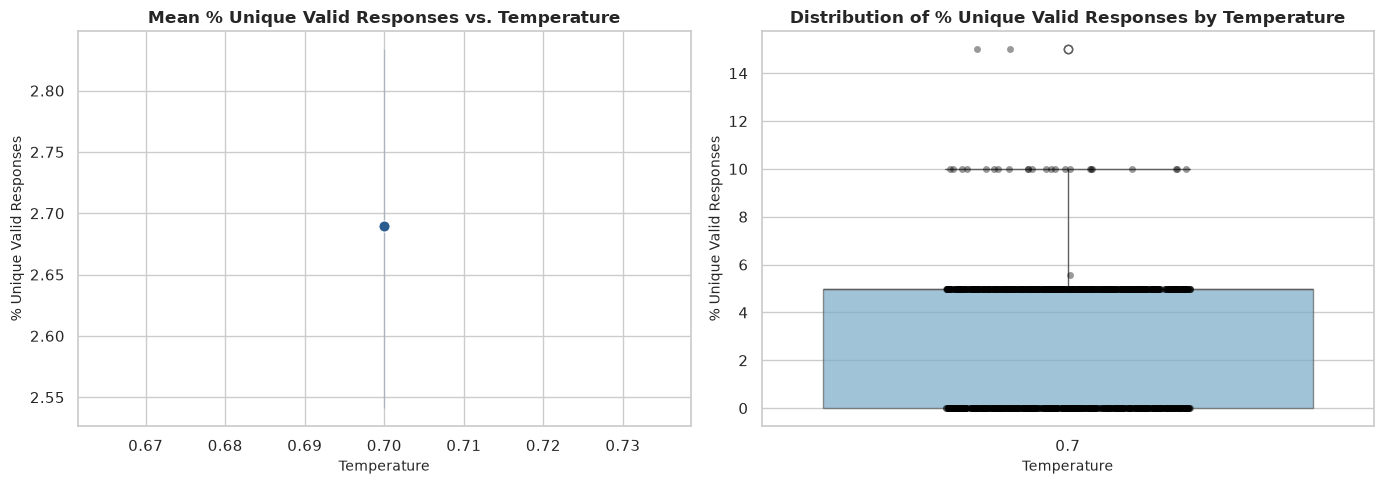

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Mean & Spread Trend Curve across Temperature ---
# Groups by temperature and plots the mean curve with 95% confidence intervals
sns.lineplot(
    data=df,
    x='temperature',
    y='pct_unique_valid',
    marker='o',
    color='#2b5c8f',
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)
axes[0].set_title('Mean % Unique Valid Responses vs. Temperature', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Temperature', fontsize=10)
axes[0].set_ylabel('% Unique Valid Responses', fontsize=10)

# --- Plot 2: Full Distribution per Temperature ---
# Shows medians, quartiles, and individual data points (jitter)
sns.boxplot(
    data=df,
    x='temperature',
    y='pct_unique_valid',
    palette='Blues',
    ax=axes[1],
    boxprops=dict(alpha=0.7)
)
sns.stripplot(
    data=df,
    x='temperature',
    y='pct_unique_valid',
    color='black',
    alpha=0.4,
    jitter=0.2,
    size=5,
    ax=axes[1]
)
axes[1].set_title('Distribution of % Unique Valid Responses by Temperature', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Temperature', fontsize=10)
axes[1].set_ylabel('% Unique Valid Responses', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_295617/2137169702.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


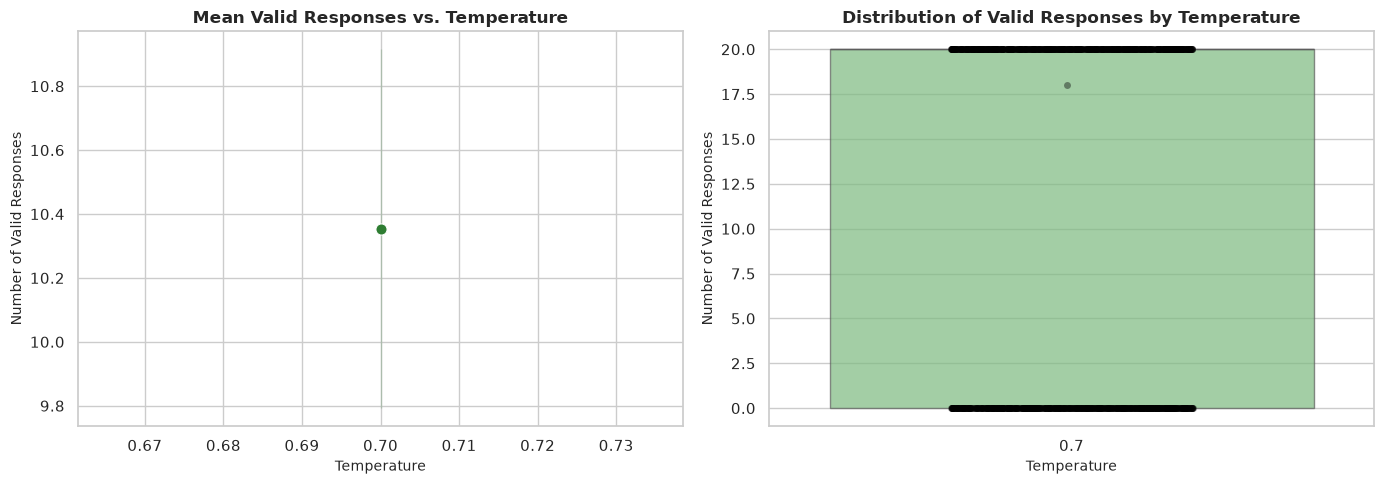

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visualization theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Mean Trend Curve ---
# Shows the average number of valid responses at each temperature with a 95% CI band
sns.lineplot(
    data=df,
    x='temperature',
    y='num_valid_responses',
    marker='o',
    color='#2e7d32',
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)
axes[0].set_title('Mean Valid Responses vs. Temperature', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Temperature', fontsize=10)
axes[0].set_ylabel('Number of Valid Responses', fontsize=10)

# --- Plot 2: Distribution Boxplot with Data Points ---
# Displays spread, median, quartiles, and individual run data points
sns.boxplot(
    data=df,
    x='temperature',
    y='num_valid_responses',
    palette='Greens',
    ax=axes[1],
    boxprops=dict(alpha=0.7)
)
sns.stripplot(
    data=df,
    x='temperature',
    y='num_valid_responses',
    color='black',
    alpha=0.4,
    jitter=0.2,
    size=5,
    ax=axes[1]
)
axes[1].set_title('Distribution of Valid Responses by Temperature', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Temperature', fontsize=10)
axes[1].set_ylabel('Number of Valid Responses', fontsize=10)

plt.tight_layout()
plt.show()

In [85]:
df[df['original_NL']==""]


,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,error_log,experiment_index,cleaned_result_output_data,num_unique_valid_responses,num_valid_responses,num_invalid_responses,pct_unique_valid
432,1150,,x2 <-> !x1\n,!x1 <-> x2,"""Max is home” : x1; ""Claire is at the library”...",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 1...",None,126,[],0,0,20,0.0
433,1151,,x2 <-> !x1\n,!x1 <-> x2,"""Max is home” : x1; ""Claire is at the library”...",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,126,[],0,0,20,0.0
434,1152,,x2 <-> !x1\n,!x1 <-> x2,"""Max is home” : x1; ""Claire is at the library”...",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",None,126,"[G(x1 -> F x2), G(x1 -> F x2), G(x1 -> F x2), ...",1,20,0,5.0
435,1153,,x2 -> (x1 & x3),x2 -> (x1 & x3),"""Folly belonged to Claire at 2:00” : x1 ; ""Cl...",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 1...",None,127,"[x1 & X(X(X x2)) & X(X(X(X(X x3)))), x1 & X(X(...",1,20,0,5.0
436,1154,,x2 -> (x1 & x3),x2 -> (x1 & x3),"""Folly belonged to Claire at 2:00” : x1 ; ""Cl...",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,127,"[x1 & FX(x2 & FX(x3)), x1 & FX(x2 & FX(x3)), x...",2,20,0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,2117,,((x1) U (x2)) & G(x1),(x1 U x2) & Gx1,"""Engine on” : x1, ""Light on” : x2",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,456,[],0,0,20,0.0
1346,2118,,((x1) U (x2)) & G(x1),(x1 U x2) & Gx1,"""Engine on” : x1, ""Light on” : x2",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",None,456,"[G(x1 -> F x2), G(x1 -> F x2), G(x1 -> F x2), ...",1,20,0,5.0
1347,2119,,G(x1 -> (X(!x1 ) & X(X(x1)))),G(x1 -> (X!x1 & XXx1)),"""Engine on” : x1",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 4...",None,457,"[x1, x1, x1, x1, x1, x1, x1, x1, x1, x1, x1, x...",1,20,0,5.0
1348,2120,,G(x1 -> (X(!x1 ) & X(X(x1)))),G(x1 -> (X!x1 & XXx1)),"""Engine on” : x1",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,457,"[G x1, G x1, G x1, G x1, G x1, G x1, G x1, G x...",1,20,0,5.0


In [69]:
import json
import ast
import pandas as pd
import spot

def parse_predicted_formula_list(cell_value) -> list[str]:
    """
    Safely extracts ALL predicted formulas from a dict/list/string structure,
    returning a list of cleaned Response strings.
    """
    # 1. Handle None or empty cases safely without triggering NumPy/Pandas array truth value errors
    if cell_value is None:
        return []
    
    # Check for scalar NaN only if cell_value is not an array/list/dict
    if not isinstance(cell_value, (list, dict, tuple)):
        try:
            if pd.isna(cell_value):
                return []
        except Exception:
            pass

    # 2. Handle String input (parse JSON or Python literal if needed)
    if isinstance(cell_value, (str, bytes, bytearray)):
        cell_value = str(cell_value).strip()
        if not cell_value:
            return []
        try:
            cell_value = json.loads(cell_value)
        except Exception:
            try:
                cell_value = ast.literal_eval(cell_value)
            except Exception:
                # Fallback if it's a plain non-JSON string formula
                return [cell_value]

    formulas = []

    # 3. Extract Response strings from list of dicts/strings
    if isinstance(cell_value, list):
        for item in cell_value:
            if isinstance(item, dict):
                resp = str(item.get("Response", "")).strip()
                if resp:
                    formulas.append(resp)
            elif isinstance(item, str) and item.strip():
                formulas.append(item.strip())

    # 4. Handle single dict input
    elif isinstance(cell_value, dict):
        resp = str(cell_value.get("Response", "")).strip()
        if resp:
            formulas.append(resp)

    return [spot.formula(f) for f in formulas]


def check_ltl_equivalence(pred_str: str, gt_str: str) -> bool:
    """Checks semantic equivalence between predicted LTL and Spot_LTL ground truth."""
    if not pred_str or not gt_str:
        return False
    try:
        f_pred = spot.formula(pred_str)
        f_gt = spot.formula(gt_str)
        return spot.are_equivalent(f_pred, f_gt)
    except Exception:
        return False


def evaluate_per_temperature(df: pd.DataFrame, 
                             pred_column: str = "result_output", 
                             gt_column: str = "Spot_LTL",
                             prompt_id_column: str = "prompt_id",
                             temp_column: str = "temperature"):
    """
    Evaluates LTL accuracy, oracle pass rates, and semantic diversity grouped by Temperature.
    """
    # 1. Clean LTL strings into lists of predicted formulas
    df["clean_pred_ltl_list"] = df['cleaned_result_output']

    temp_summaries = []
    
    # Group evaluation by each Temperature setting
    for temp, temp_group in df.groupby(temp_column):
        prompt_metrics = []
        
        for prompt_id, p_group in temp_group.groupby(prompt_id_column):
            gt_formula = str(p_group[gt_column].iloc[0]).strip()
            
            # Flatten all predicted formula lists for this prompt ID at this temperature
            preds = [
                pred 
                for sublist in p_group["clean_pred_ltl_list"].tolist() 
                for pred in sublist
            ]
            
            if not preds:
                prompt_metrics.append({
                    "pass_1": 0.0,
                    "pass_n": False,
                    "majority_correct": False,
                    "semantic_clusters": 0,
                    "syntax_error_rate": 1.0
                })
                continue

            # Evaluate equivalence for each prediction
            matches = [check_ltl_equivalence(p, gt_formula) for p in preds]
            
            # Pass@1: Average accuracy across all generated responses for this prompt
            pass_1 = sum(matches) / len(matches)
            
            # Pass@N (Oracle): Did ANY generated response hit ground truth?
            pass_n = any(matches)
            
            # Group into canonical equivalence classes using Spot
            canonical_counts = {}
            syntax_errors = 0
            for p in preds:
                try:
                    canon_str = spot.formula(p).to_str()
                    canonical_counts[canon_str] = canonical_counts.get(canon_str, 0) + 1
                except Exception:
                    syntax_errors += 1

            # Majority Vote accuracy
            if canonical_counts:
                top_canon = max(canonical_counts, key=canonical_counts.get)
                majority_correct = check_ltl_equivalence(top_canon, gt_formula)
            else:
                majority_correct = False
                
            prompt_metrics.append({
                "pass_1": pass_1,
                "pass_n": pass_n,
                "majority_correct": majority_correct,
                "semantic_clusters": len(canonical_counts),
                "syntax_error_rate": syntax_errors / len(preds)
            })
            
        p_df = pd.DataFrame(prompt_metrics)
        
        temp_summaries.append({
            "Temperature": temp,
            "Total Prompts": len(p_df),
            "Mean Pass@1 Acc (%)": round(p_df["pass_1"].mean() * 100, 2),
            "Oracle Pass@N Acc (%)": round(p_df["pass_n"].mean() * 100, 2),
            "Majority Vote Acc (%)": round(p_df["majority_correct"].mean() * 100, 2),
            "Avg Clusters / Prompt": round(p_df["semantic_clusters"].mean(), 2),
            "Syntax Error Rate (%)": round(p_df["syntax_error_rate"].mean() * 100, 2)
        })

    summary_df = pd.DataFrame(temp_summaries).sort_values(by="Temperature")
    
    print("=== Per-Temperature Performance Summary ===")
    print(summary_df.to_string(index=False))
    
    return df, summary_df


df['clean_pred_ltl_list'] = df['cleaned_result_output'].apply(
    lambda x: json.loads(x) if pd.notna(x) and isinstance(x, (str, bytes)) else []
)


annotated_df, summary_table = evaluate_per_temperature(

df,

pred_column="result_output",

gt_column="Spot_LTL",

prompt_id_column="id",

temp_column="temperature"

)

KeyError: 'cleaned_result_output'

In [71]:
df

,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,error_log,experiment_index,num_unique_valid_responses,num_valid_responses,num_invalid_responses,pct_unique_valid
0,1,The Inner Loop Roll Regulator Shall not comman...,(G(!transient_angular_roll_acceleration_change...,G!transient_angular_roll_acceleration_change_g...,{transient_angular_roll_acceleration_change_gr...,BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",None,2,1,20,0,5.0
1,2,The Inner Loop Roll Regulator Shall not comman...,(G(!transient_angular_roll_acceleration_change...,G!transient_angular_roll_acceleration_change_g...,{transient_angular_roll_acceleration_change_gr...,ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,2,1,20,0,5.0
2,3,The Inner Loop Roll Regulator Shall not comman...,(G(!transient_angular_roll_acceleration_change...,G!transient_angular_roll_acceleration_change_g...,{transient_angular_roll_acceleration_change_gr...,ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",None,2,1,20,0,5.0
3,4,The sensor shall change states from NOMINAL to...,!limits U (limits & F(state_is_FAULT)),!limits U (limits & Fstate_is_FAULT),"{limits, state_is_FAULT}",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 3...",None,3,1,20,0,5.0
4,5,The sensor shall change states from NOMINAL to...,!limits U (limits & F(state_is_FAULT)),!limits U (limits & Fstate_is_FAULT),"{limits, state_is_FAULT}",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,3,1,20,0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,2117,,((x1) U (x2)) & G(x1),(x1 U x2) & Gx1,"""Engine on” : x1, ""Light on” : x2",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,456,0,0,20,0.0
1346,2118,,((x1) U (x2)) & G(x1),(x1 U x2) & Gx1,"""Engine on” : x1, ""Light on” : x2",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",None,456,1,20,0,5.0
1347,2119,,G(x1 -> (X(!x1 ) & X(X(x1)))),G(x1 -> (X!x1 & XXx1)),"""Engine on” : x1",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 4...",None,457,1,20,0,5.0
1348,2120,,G(x1 -> (X(!x1 ) & X(X(x1)))),G(x1 -> (X!x1 & XXx1)),"""Engine on” : x1",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",None,457,1,20,0,5.0


In [ ]:
import json
sample_row = df[df['temperature'] == 0.8].iloc[11]
retakes = [item['Response'] for item in json.loads(sample_row['result_output'])]

print("Total retakes:", len(retakes))
print("Unique formulas generated:", len(set(retakes)))

Total retakes: 20
Unique formulas generated: 3


/tmp/ipykernel_45672/401684148.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


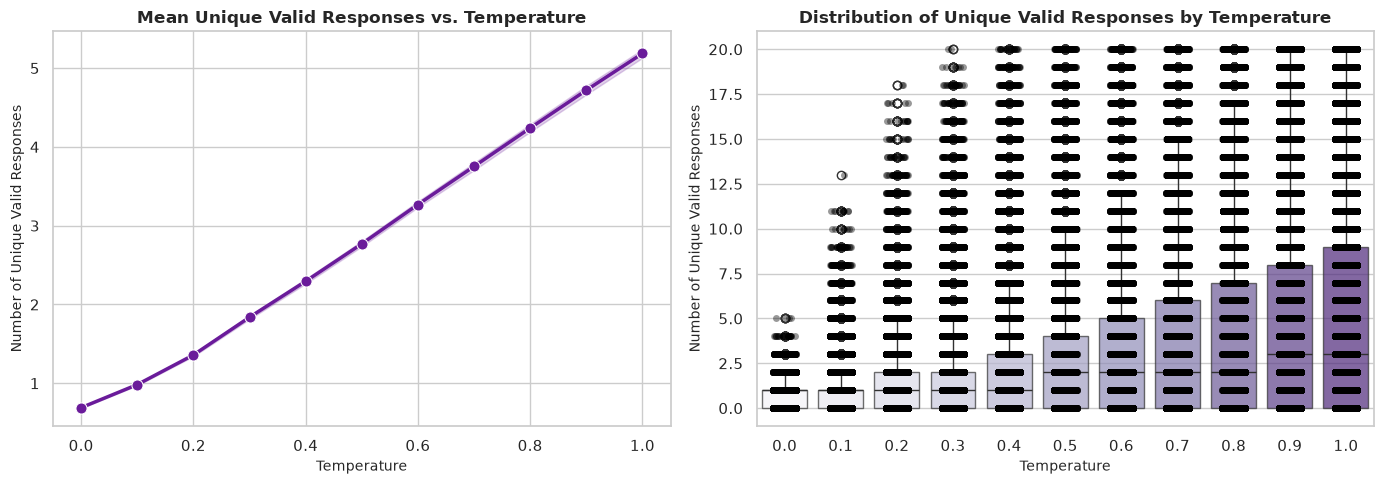

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visualization theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Mean Trend Curve ---
# Shows the average count of unique valid responses per temperature with a 95% CI band
sns.lineplot(
    data=df,
    x='temperature',
    y='num_unique_valid_responses',
    marker='o',
    color='#6a1b9a',
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)
axes[0].set_title('Mean Unique Valid Responses vs. Temperature', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Temperature', fontsize=10)
axes[0].set_ylabel('Number of Unique Valid Responses', fontsize=10)

# --- Plot 2: Distribution Boxplot with Raw Data Points ---
# Displays spread, median, quartiles, and individual run data points
sns.boxplot(
    data=df,
    x='temperature',
    y='num_unique_valid_responses',
    palette='Purples',
    ax=axes[1],
    boxprops=dict(alpha=0.7)
)
sns.stripplot(
    data=df,
    x='temperature',
    y='num_unique_valid_responses',
    color='black',
    alpha=0.4,
    jitter=0.2,
    size=5,
    ax=axes[1]
)
axes[1].set_title('Distribution of Unique Valid Responses by Temperature', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Temperature', fontsize=10)
axes[1].set_ylabel('Number of Unique Valid Responses', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_45672/2807182336.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


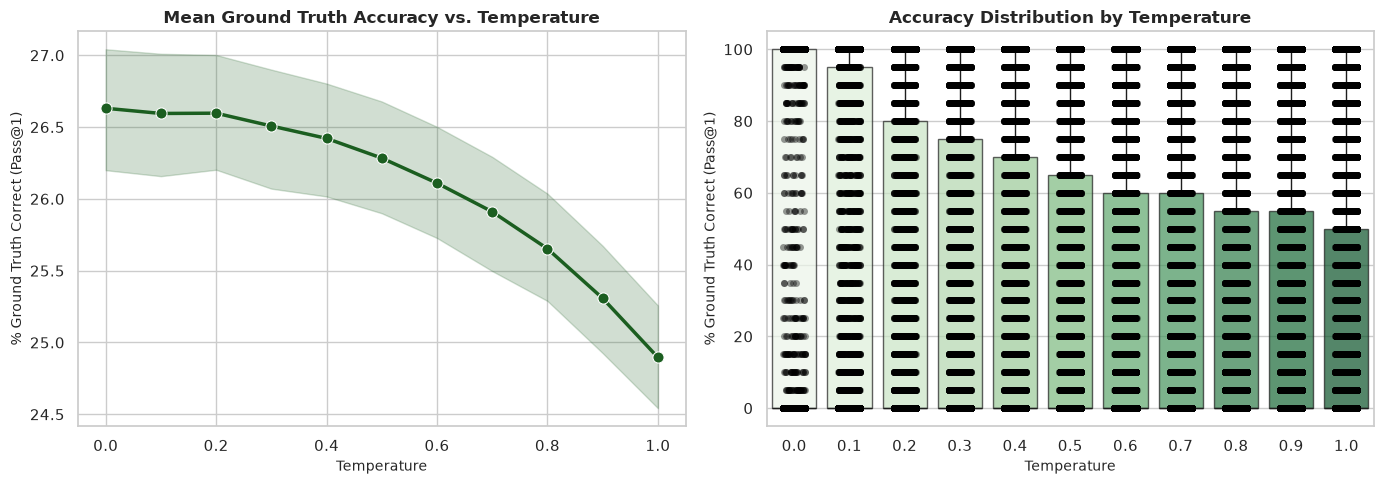

=== Ground Truth Prediction Accuracy by Temperature ===
 temperature  Mean_Accuracy_Pct  Median_Accuracy_Pct  Std_Dev  Total_Experiments
         0.0              26.63                  0.0    44.08              43008
         0.1              26.59                  0.0    43.62              43008
         0.2              26.60                  0.0    43.15              43008
         0.3              26.51                  0.0    42.63              43008
         0.4              26.42                  0.0    42.17              43008
         0.5              26.28                  0.0    41.70              43008
         0.6              26.11                  0.0    41.18              43008
         0.7              25.91                  0.0    40.66              43008
         0.8              25.65                  0.0    40.04              43008
         0.9              25.31                  0.0    39.40              43008
         1.0              24.90                  0.0 

In [ ]:
import pandas as pd
import spot
import matplotlib.pyplot as plt
import seaborn as sns

def check_ltl_equivalence(pred_str: str, gt_str: str) -> bool:
    """Checks semantic equivalence between predicted LTL and Ground Truth using Spot."""
    if not pred_str or not gt_str:
        return False
    try:
        f_pred = spot.formula(pred_str)
        f_gt = spot.formula(gt_str)
        return spot.are_equivalent(f_pred, f_gt)
    except Exception:
        return False

def calculate_row_accuracy(row, pred_col="clean_pred_ltl_list", gt_col="Spot_LTL"):
    """
    Calculates the % of generated formulas in a row that match Ground Truth.
    """
    preds = row[pred_col]
    gt_formula = str(row[gt_col]).strip()
    
    if not isinstance(preds, list) or len(preds) == 0:
        return 0.0
    
    # Count how many predictions in the list are semantically correct
    correct_count = sum(1 for p in preds if check_ltl_equivalence(p, gt_formula))
    
    # Return percentage (0 to 100%)
    return (correct_count / len(preds)) * 100.0

# --- 1. Compute Individual Row Accuracy ---
df['pct_ground_truth_correct'] = df.apply(calculate_row_accuracy, axis=1)

# --- 2. Plotting Accuracy vs. Temperature ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean Accuracy Trend Curve across Temperature
sns.lineplot(
    data=df,
    x='temperature',
    y='pct_ground_truth_correct',
    marker='o',
    color='#1b5e20',
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)
axes[0].set_title('Mean Ground Truth Accuracy vs. Temperature', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Temperature', fontsize=10)
axes[0].set_ylabel('% Ground Truth Correct (Pass@1)', fontsize=10)

# Plot 2: Distribution Boxplot with Raw Data Points
sns.boxplot(
    data=df,
    x='temperature',
    y='pct_ground_truth_correct',
    palette='Greens',
    ax=axes[1],
    boxprops=dict(alpha=0.7)
)
sns.stripplot(
    data=df,
    x='temperature',
    y='pct_ground_truth_correct',
    color='black',
    alpha=0.4,
    jitter=0.2,
    size=5,
    ax=axes[1]
)
axes[1].set_title('Accuracy Distribution by Temperature', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Temperature', fontsize=10)
axes[1].set_ylabel('% Ground Truth Correct (Pass@1)', fontsize=10)

plt.tight_layout()
plt.show()

# --- 3. Summary Table by Temperature ---
summary_accuracy = df.groupby('temperature')['pct_ground_truth_correct'].agg(
    Mean_Accuracy_Pct='mean',
    Median_Accuracy_Pct='median',
    Std_Dev='std',
    Total_Experiments='count'
).reset_index().round(2)

print("=== Ground Truth Prediction Accuracy by Temperature ===")
print(summary_accuracy.to_string(index=False))

In [53]:
import json
import ast
import pandas as pd
import spot

def parse_and_canonicalize_ltl_list(cell_value) -> list[str]:
    """
    Extracts formulas from result_output, parses each with spot.formula(),
    and converts it to its canonical Spot string representation.
    Filters out any invalid syntax.
    """
    if cell_value is None:
        return []
    
    # Avoid truth-value ambiguity for containers
    if not isinstance(cell_value, (list, dict, tuple)):
        try:
            if pd.isna(cell_value):
                return []
        except Exception:
            pass

    # 1. Parse string to Python structure
    if isinstance(cell_value, (str, bytes, bytearray)):
        cell_value = str(cell_value).strip()
        if not cell_value:
            return []
        try:
            cell_value = json.loads(cell_value)
        except Exception:
            try:
                cell_value = ast.literal_eval(cell_value)
            except Exception:
                cell_value = [cell_value]

    raw_formulas = []

    # 2. Extract raw formula strings
    if isinstance(cell_value, list):
        for item in cell_value:
            if isinstance(item, dict):
                resp = str(item.get("Response", "")).strip()
                if resp:
                    raw_formulas.append(resp)
            elif isinstance(item, str) and item.strip():
                raw_formulas.append(item.strip())
    elif isinstance(cell_value, dict):
        resp = str(cell_value.get("Response", "")).strip()
        if resp:
            raw_formulas.append(resp)

    # 3. Transform each formula with spot.formula() -> str
    canonical_formulas = []
    for f_str in raw_formulas:
        try:
            # Parse with Spot and convert to canonical string representation
            canon_str = spot.formula(f_str).to_str()
            canonical_formulas.append(canon_str)
        except Exception:
            # Skip formulas that cause spot parsing errors
            continue

    return canonical_formulas


# --- Apply to your DataFrame ---
df["clean_pred_ltl_list"] = df["clean_pred_ltl_list"].apply(parse_and_canonicalize_ltl_list)

# Verify the output format on the first row
print("Sample cleaned Spot formulas (as strings):")
print(df["clean_pred_ltl_list"].iloc[0])

Sample cleaned Spot formulas (as strings):
['keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear', 'keep_apple U drop_pear']


In [54]:
df2 = df[df['num_unique_valid_responses'] > 1]
df2

,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,...,experiment_index,num_unique_valid_responses,num_valid_responses,num_invalid_responses,pct_unique_valid,cleaned_result_output,clean_pred_ltl,is_semantic_correct,clean_pred_ltl_list,pct_ground_truth_correct
10,11,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,1.0,COMPLETED,NaN,"[{'PROMPTTYPE': 'BASIC', 'experiment_index': 2...",...,2,2,20,0,10.0,"[{'PROMPTTYPE': 'BASIC', 'experiment_index': 2...",keep_apple U drop_pear,True,"[keep_apple U drop_pear, keep_apple U drop_pea...",95.0
21,22,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",ARTEMIS,1.0,COMPLETED,NaN,"[{'PROMPTTYPE': 'ARTEMIS', 'experiment_index':...",...,2,2,20,0,10.0,"[{'PROMPTTYPE': 'ARTEMIS', 'experiment_index':...",keep_apple U drop_pear,True,"[keep_apple U drop_pear, keep_apple U drop_pea...",95.0
38,39,"after the train has arrived, finally, either a...",G(( train_has_arrived ) -> F( semaphore_is_red...,G(train_has_arrived -> F(escalator_speeds_up |...,"['semaphore_is_red', 'escalator_speeds_up', 't...",BASIC,0.5,COMPLETED,NaN,"[{'PROMPTTYPE': 'BASIC', 'experiment_index': 3...",...,3,2,20,0,10.0,"[{'PROMPTTYPE': 'BASIC', 'experiment_index': 3...",G (train_has_arrived -> F (semaphore_is_red | ...,True,[G(train_has_arrived -> F(escalator_speeds_up ...,100.0
39,40,"after the train has arrived, finally, either a...",G(( train_has_arrived ) -> F( semaphore_is_red...,G(train_has_arrived -> F(escalator_speeds_up |...,"['semaphore_is_red', 'escalator_speeds_up', 't...",BASIC,0.6,COMPLETED,NaN,"[{'PROMPTTYPE': 'BASIC', 'experiment_index': 3...",...,3,2,20,0,10.0,"[{'PROMPTTYPE': 'BASIC', 'experiment_index': 3...",G(train_has_arrived -> F(semaphore_is_red | es...,True,[G(train_has_arrived -> F(escalator_speeds_up ...,100.0
40,41,"after the train has arrived, finally, either a...",G(( train_has_arrived ) -> F( semaphore_is_red...,G(train_has_arrived -> F(escalator_speeds_up |...,"['semaphore_is_red', 'escalator_speeds_up', 't...",BASIC,0.7,COMPLETED,NaN,"[{'PROMPTTYPE': 'BASIC', 'experiment_index': 3...",...,3,3,20,0,15.0,"[{'PROMPTTYPE': 'BASIC', 'experiment_index': 3...",G(train_has_arrived -> F(semaphore_is_red | es...,True,[G(train_has_arrived -> F(escalator_speeds_up ...,95.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473083,473084,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.6,COMPLETED,NaN,"[{'PROMPTTYPE': 'ADARULE', 'experiment_index':...",...,14337,6,20,0,30.0,"[{'PROMPTTYPE': 'ADARULE', 'experiment_index':...",G((prop_1 -> F(prop_2)) & prop_3),False,"[G(prop_3 & (prop_1 -> Fprop_2)), G(prop_3 & (...",0.0
473084,473085,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.7,COMPLETED,NaN,"[{'PROMPTTYPE': 'ADARULE', 'experiment_index':...",...,14337,8,20,0,40.0,"[{'PROMPTTYPE': 'ADARULE', 'experiment_index':...",G((prop_1) -> (prop_2) & (prop_3)),False,"[G(prop_1 -> (prop_2 & prop_3)), G(prop_1 -> (...",0.0
473085,473086,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.8,COMPLETED,NaN,"[{'PROMPTTYPE': 'ADARULE', 'experiment_index':...",...,14337,11,20,0,55.0,"[{'PROMPTTYPE': 'ADARULE', 'experiment_index':...",G((prop_1 -> F(prop_2)) & prop_3),False,"[G(prop_3 & (prop_1 -> Fprop_2)), G(prop_1 -> ...",0.0
473086,473087,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.9,COMPLETED,NaN,"[{'PROMPTTYPE': 'ADARULE', 'experiment_index':...",...,14337,7,20,0,35.0,"[{'P

In [55]:
from collections import Counter
import pandas as pd

def check_multiple_modes(ltl_list):
    """
    Checks if there are multiple 'most frequent' elements (a tie for top frequency).
    
    Returns:
        bool: True if there is a tie for the most frequent formula, 
              False if there is a single clear winner (or list is empty).
    """
    if not isinstance(ltl_list, list) or len(ltl_list) == 0:
        return False
    
    # Count occurrences of each formula
    counts = Counter(ltl_list)
    
    # Find the maximum frequency count
    max_count = max(counts.values())
    
    # Count how many unique formulas achieved this maximum frequency
    most_frequent_elements = [formula for formula, count in counts.items() if count == max_count]
    
    # True if there are 2 or more formulas tied for top spot
    return len(most_frequent_elements) > 1


def get_top_frequent_elements(ltl_list):
    """
    Helper function to return the list of tied top elements and their frequency.
    """
    if not isinstance(ltl_list, list) or len(ltl_list) == 0:
        return [], 0
    
    counts = Counter(ltl_list)
    max_count = max(counts.values())
    top_elements = [formula for formula, count in counts.items() if count == max_count]
    
    return top_elements, max_count


# ==========================================
# Applying to your DataFrame
# ==========================================

# 1. Flag rows that have a tie for the most frequent formula
df2['has_frequent_tie'] = df2['clean_pred_ltl_list'].apply(check_multiple_modes)

# 2. (Optional) Extract the top elements and their count for inspection
df2['top_formulas'], df2['top_count'] = zip(*df2['clean_pred_ltl_list'].apply(get_top_frequent_elements))

# Print summary
tie_count = df2['has_frequent_tie'].sum()
print(f"Total rows evaluated: {len(df2)}")
print(f"Rows with a tie for most frequent formula: {tie_count} ({tie_count / len(df2) * 100:.2f}%)")

Total rows evaluated: 207869
Rows with a tie for most frequent formula: 11419 (5.49%)


In [56]:
tied_rows = df2[df2['has_frequent_tie']]

for idx, row in tied_rows.head(5).iterrows():
    print(f"Prompt ID: {row.get('prompt_id', idx)}")
    print(f"Top Count: {row['top_count']} votes each")
    print("Tied Formulas:")
    for formula in row['top_formulas']:
        print(f"  - {formula}")
    print("-" * 50)

Prompt ID: 240
Top Count: 2 votes each
Tied Formulas:
  - F(red_room | yellow_room) U Fblue_room
  - Fyellow_room | Fred_room | Fblue_room
--------------------------------------------------
Prompt ID: 243
Top Count: 9 votes each
Tied Formulas:
  - F(blue_room & (G!blue_room U (red_room | yellow_room)))
  - F((red_room | yellow_room) & Xblue_room)
--------------------------------------------------
Prompt ID: 244
Top Count: 7 votes each
Tied Formulas:
  - F(blue_room & (G!blue_room U (red_room | yellow_room)))
  - F((red_room | yellow_room) & Xblue_room)
--------------------------------------------------
Prompt ID: 251
Top Count: 3 votes each
Tied Formulas:
  - G((red_room | yellow_room) -> Fblue_room)
  - G(red_room | yellow_room) U blue_room
--------------------------------------------------
Prompt ID: 291
Top Count: 4 votes each
Tied Formulas:
  - GFcharger_5 & G(photo & region_4)
  - G(Fcharger_5 & G(photo & region_4))
--------------------------------------------------


=== Strict Majority Vote Accuracy vs. Temperature ===
 temperature  majority_acc_pct  total_runs
         0.0             26.60       43008
         0.1             26.53       43008
         0.2             26.64       43008
         0.3             26.72       43008
         0.4             26.84       43008
         0.5             26.90       43008
         0.6             26.96       43008
         0.7             27.19       43008
         0.8             27.22       43008
         0.9             27.30       43008
         1.0             27.39       43008


/tmp/ipykernel_45672/3558599721.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


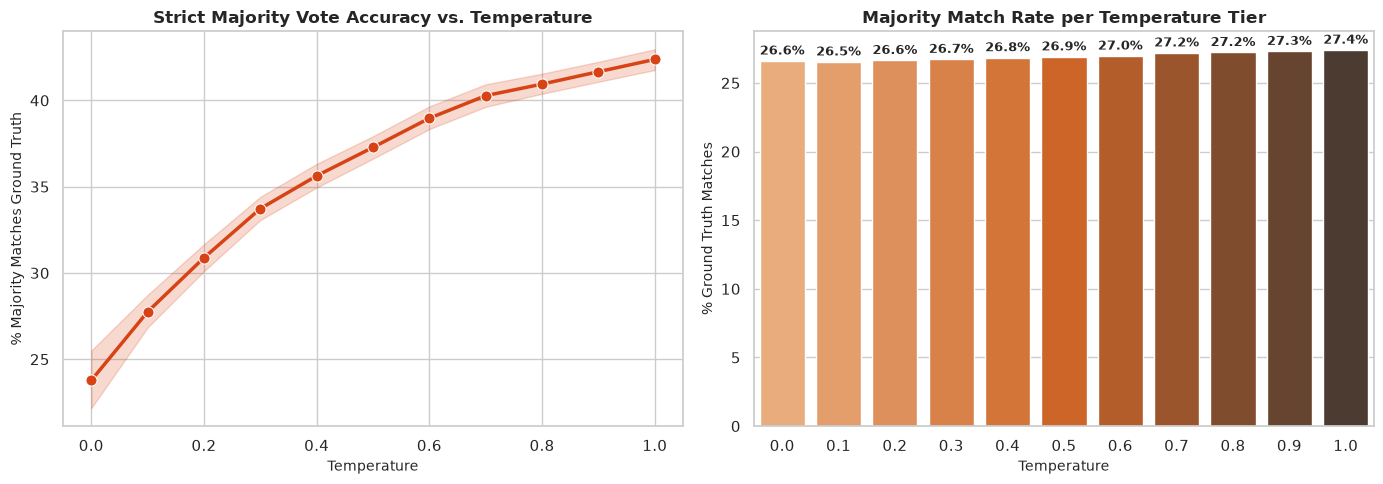

In [60]:
from collections import Counter
import pandas as pd
import spot
import matplotlib.pyplot as plt
import seaborn as sns

def check_ltl_equivalence(pred_str: str, gt_str: str) -> bool:
    """Checks semantic equivalence between predicted LTL and Ground Truth using Spot."""
    if not pred_str or not gt_str:
        return False
    try:
        f_pred = spot.formula(pred_str)
        f_gt = spot.formula(gt_str)
        return spot.are_equivalent(f_pred, f_gt)
    except Exception:
        return False

def check_strict_majority_match(row, pred_col="clean_pred_ltl_list", gt_col="Spot_LTL") -> bool:
    """
    Finds the most common element in clean_pred_ltl_list.
    - If empty -> False
    - If there is a tie for the most common element -> False (Strict Fail)
    - Otherwise -> Checks equivalence of top element vs Spot_LTL
    """
    preds = row[pred_col]
    gt_formula = str(row[gt_col]).strip()
    
    if not isinstance(preds, list) or len(preds) == 0:
        return False
    
    # Count frequency of each canonical formula string
    counts = Counter(preds)
    most_common = counts.most_common()
    
    # Check for a tie at the top frequency
    if len(most_common) > 1 and most_common[0][1] == most_common[1][1]:
        return False  # Tie for most common element counts as a fail
    
    # Extract the single winner
    top_formula = most_common[0][0]
    
    # Check semantic equivalence against ground truth
    return check_ltl_equivalence(top_formula, gt_formula)

# --- 1. Compute Strict Majority Match per Row ---
df2['is_majority_correct'] = df2.apply(check_strict_majority_match, axis=1)

# --- 2. Calculate Percentage per Temperature ---
# Convert boolean (True/False) to percentage (0% to 100%)
majority_summary = df.groupby('temperature')['is_majority_correct'].agg(
    majority_acc_pct=lambda x: x.mean() * 100.0,
    total_runs='count'
).reset_index().round(2)

print("=== Strict Majority Vote Accuracy vs. Temperature ===")
print(majority_summary.to_string(index=False))

# --- 3. Visualization ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Line Chart (Majority Accuracy Curve across Temperature)
sns.lineplot(
    data=df2,
    x='temperature',
    y='is_majority_correct',
    estimator=lambda x: x.mean() * 100,
    marker='o',
    color='#d84315',
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)
axes[0].set_title('Strict Majority Vote Accuracy vs. Temperature', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Temperature', fontsize=10)
axes[0].set_ylabel('% Majority Matches Ground Truth', fontsize=10)

# Plot 2: Bar Chart showing exact percentage per temperature tier
sns.barplot(
    data=majority_summary,
    x='temperature',
    y='majority_acc_pct',
    palette='Oranges_d',
    ax=axes[1]
)
axes[1].set_title('Majority Match Rate per Temperature Tier', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Temperature', fontsize=10)
axes[1].set_ylabel('% Ground Truth Matches', fontsize=10)

# Annotate bars with exact percentage values
for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 7),
        textcoords='offset points',
        fontsize=9, fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [61]:
import pandas as pd
import spot

def check_semantic_hit(ltl_list, gt_str):
    """
    Checks if AT LEAST ONE formula in the list is semantically equivalent 
    to the ground truth formula using Spot.
    """
    if not isinstance(ltl_list, list) or len(ltl_list) == 0:
        return False
    
    gt_str = str(gt_str).strip()
    if not gt_str:
        return False

    try:
        f_gt = spot.formula(gt_str)
    except Exception:
        return False  # Ground truth formula failed to parse

    for pred in ltl_list:
        pred_str = str(pred).strip()
        if not pred_str:
            continue
        try:
            f_pred = spot.formula(pred_str)
            if spot.are_equivalent(f_pred, f_gt):
                return True  # Found at least one correct formula!
        except Exception:
            continue  # Ignore invalid LTL predictions

    return False


def check_exact_hit(ltl_list, gt_str):
    """
    Checks if AT LEAST ONE formula in the list exact-string matches ground truth.
    """
    if not isinstance(ltl_list, list) or len(ltl_list) == 0:
        return False
    
    gt_clean = str(gt_str).strip()
    return any(str(p).strip() == gt_clean for p in ltl_list)


def evaluate_oracle_per_temperature(df, 
                                     list_col="clean_pred_ltl_list", 
                                     gt_col="Spot_LTL", 
                                     temp_col="temperature"):
    """
    Evaluates how often ANY retake in the list got the ground truth formula right,
    grouped by temperature.
    """
    df = df.copy()

    # 1. Row-level checks: Did ANY element in clean_pred_ltl_list hit ground truth?
    df["oracle_semantic_hit"] = df.apply(
        lambda r: check_semantic_hit(r[list_col], r[gt_col]), axis=1
    )
    df["oracle_exact_hit"] = df.apply(
        lambda r: check_exact_hit(r[list_col], r[gt_col]), axis=1
    )

    # 2. Aggregate per temperature
    summary = []
    for temp, group in df.groupby(temp_col):
        total_rows = len(group)
        semantic_hits = group["oracle_semantic_hit"].sum()
        exact_hits = group["oracle_exact_hit"].sum()

        summary.append({
            "Temperature": temp,
            "Total Rows": total_rows,
            "Oracle Semantic Match (%)": round((semantic_hits / total_rows) * 100, 2),
            "Oracle Exact Match (%)": round((exact_hits / total_rows) * 100, 2),
            "Semantic Hit Count": semantic_hits,
            "Exact Hit Count": exact_hits
        })

    summary_df = pd.DataFrame(summary).sort_values(by="Temperature")

    print("=== Oracle Accuracy Across Retakes (Temperature vs. Any Match) ===")
    print(summary_df.to_string(index=False))

    return df, summary_df

# ==========================================
# Example Usage
# ==========================================
annotated_df, temp_summary = evaluate_oracle_per_temperature(
    df2, 
    list_col="clean_pred_ltl_list", 
    gt_col="Spot_LTL", 
    temp_col="temperature"
)

=== Oracle Accuracy Across Retakes (Temperature vs. Any Match) ===
 Temperature  Total Rows  Oracle Semantic Match (%)  Oracle Exact Match (%)  Semantic Hit Count  Exact Hit Count
         0.0        2549                      31.03                   15.18                 791              387
         0.1        9211                      35.94                   19.35                3310             1782
         0.2       13714                      39.97                   21.52                5481             2951
         0.3       17550                      43.81                   24.14                7689             4237
         0.4       19823                      46.38                   25.89                9193             5133
         0.5       21599                      49.17                   27.71               10620             5985
         0.6       23137                      52.02                   29.75               12036             6883
         0.7       24117     